# Examen Diplomado de Ciencia de Datos - Modulo1

La unidad muestral a trabajar sera rating.

# Importar librerias

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from varclushi import VarClusHi

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.feature_selection import SelectKBest, f_classif

import plotly.graph_objects as go

from sklearn.impute import SimpleImputer



In [42]:
# Importar todas las funciones del paquete funciones
from funciones import *

# Importar los conjuntos de datos

In [43]:
ratings = pd.read_csv(r"datos/ratings.csv", low_memory=False)
users = pd.read_csv(r"datos/users.csv", low_memory=False)
usercuisine = pd.read_csv(r"datos/usercuisine.csv", low_memory=False)
restaurants = pd.read_csv(r"datos/restaurants.csv", low_memory=False)
cuisine = pd.read_csv(r"datos/cuisine.csv", low_memory=False)

# Ingenieria de datos

Teniendo muy presente la unidad muestral, genere al menos 5 variables adicionales a las proporcionadas individualmente.

In [44]:
# unir rating con users y ratings
df = ratings.merge(users, on="userID", how="left")
# Unir información de restaurantes
df = df.merge(restaurants, on="placeID", how="left", suffixes=("_user", "_rest"))
# Unir preferencias de cocina del usuario
df = df.merge(usercuisine, on="userID", how="left", suffixes=("", "_userpref"))
# Unir tipos de cocina del restaurante
df = df.merge(cuisine, on="placeID", how="left", suffixes=("", "_restcuisine"))

In [45]:
df['userID'] = df['userID'].astype('string')

In [46]:
df_original = df.copy()

primer variable adicional

In [47]:
# crear la variable de edad
df["age"] = 2025 - df["birth_year"]

segunda variable adicional

In [48]:
# crear la variable de distancia entre usuario y restaurante
# usa latitud_user, latitud_rest, longitud_user, longitud_rest
df["dist_user_restaurant"] = np.sqrt(
    (df["latitude_user"] - df["latitude_rest"])**2 +
    (df["longitude_user"] - df["longitude_rest"])**2
)

tercer variable adicional

In [49]:
# Ver si la cocina del restaurante coincide con la preferida del usuario
df["match_cuisine"] = (df["Rcuisine"] == df["Rcuisine_restcuisine"]).fillna(False).astype(int)

cuarta variable adicional

In [50]:
popularity = ratings.groupby("placeID")["rating"].count().rename("restaurant_popularity")
df = df.merge(popularity, on="placeID", how="left")

quinta variable adicional

In [51]:
df['rating_comida_service'] = 0.5 * df['food_rating'] + 0.5 * df['service_rating']

sexta variable adicional

In [52]:
# variable de si hace match la ambience del usuario y del restaurante
df["preference_ambience_match"] = df.apply(
    lambda row: ambience_match(row["ambience"], row["Rambience"]),
    axis=1
)

# Construcción de variable objetivo

Genera la variable objetivo que quiere estimar, ya sea continua o categórica.

Nuestra variable objetivo que tomaremos va ser la calificacion general que le dio el usuario al restaurante, no tiene valores faltantes.

La podemos modificar para tener una variable binaria y poder ejecutar IV y WoE

In [53]:
df['rating'].value_counts(dropna=False)

rating
0    2124
2    1102
1     834
Name: count, dtype: int64

In [54]:
# Si es 1 o 2, ponerlo como 1
df['rating'] = df['rating'].apply(lambda x: 1 if x in [1, 2] else x)

# Limpieza de datos

De acuerdo con lo visto en clase, identifique si es necesario la aplicación de los procesos que se listan a continuación:

– Detección y remoción de valores extremos. 

– Detección y remoción de variables poco pobladas. 65% 

– Detección y tratamiento de valores ausentes. 

– Remoción de variables altamente correlacionadas. Remueva solo aquellas con correlación 1 en valor absoluto.

– Detección y remoción de variables unitarias (unarias). 

En caso de que algún proceso no sea necesario, justifique. 

## Detección y remoción de variables unitarias (unarias)

In [55]:
df.isnull().sum().sort_values(ascending=False).head(1)

Rcuisine_restcuisine    631
dtype: int64

Notamos que solo una variable tiene variables ausentes, pero esto es por que en algunos casos las variables string tienen el parametro de none o ?, como parametro por tanto se analizara a detalle para modificarlos y convertirlos a valor faltante.

In [56]:
# Mostra de cada columna los values counts solo de las columnas que son object
for col in df.select_dtypes(include=['object']).columns:
    print(f"Value counts for column '{col}':")
    print(df[col].value_counts(dropna=False))
    print("\n")

Value counts for column 'smoker':
smoker
false    3763
true      259
?          38
Name: count, dtype: int64


Value counts for column 'drink_level':
drink_level
casual drinker    2751
abstemious         806
social drinker     503
Name: count, dtype: int64


Value counts for column 'dress_preference':
dress_preference
informal         2583
no preference     700
formal            634
elegant            72
?                  71
Name: count, dtype: int64


Value counts for column 'ambience':
ambience
family      2623
friends      928
solitary     442
?             67
Name: count, dtype: int64


Value counts for column 'transport':
transport
on foot      2154
public       1225
car owner     620
?              61
Name: count, dtype: int64


Value counts for column 'marital_status':
marital_status
single     3916
married      75
?            47
widow        22
Name: count, dtype: int64


Value counts for column 'hijos':
hijos
independent    2015
kids           1902
?               114
depend

La variable smoker, dress_preference, ambience, transport, marital_status, hijos, activity, budget, address, city, state, country, fax, zip, url tienen `?`

La variable interest, religion, smoking_area, other_services  tienen `none`

La variable url tiene `no`

Notar que en state se debe de unificar ya que tenemos, San Luis Potosi, san luis potosi, s.l.p.,S.L.P. etc.

Igual para country, notando que es unitaria
fax, tiene todo nulo.

Notando que country es unitaria, al igual que fax

Aplicar normalizacion: 

smoker es una variable bolleana (false, true), franchise (f, t)

Unificar name, city, state, country (Mexico, mexico)

Ver si se tiene que unificar: Rcuisine_restcuisine y Rcuisine (se ve unificada)

In [57]:
# Normalización para city
df["city"] = (
    df["city"]
    .astype("string")
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.replace(r"[\.]", "", regex=True)
    .str.strip()
)

# Diccionario para ciudades equivalentes
city_map = {
    # SAN LUIS POTOSÍ (todas sus variantes)
    "san luis potosi": "san luis potosi",
    "san luis potos": "san luis potosi",
    "san luis potos ": "san luis potosi",
    "slp": "san luis potosi",

    # CIUDAD VICTORIA (todas las variantes)
    "victoria": "ciudad victoria",
    "ciudad victoria": "ciudad victoria",
    "cd victoria": "ciudad victoria",
    "cd victoria ": "ciudad victoria",
    "cd  victoria": "ciudad victoria",
    "cdvictoria": "ciudad victoria",

    # CUERNAVACA
    "cuernavaca": "cuernavaca",

    # SOLEDAD, JIUTEPEC (ya correctos)
    "soledad": "soledad",
    "jiutepec": "jiutepec",
}

# Unificación
df["city"] = df["city"].map(city_map).fillna(df["city"])

In [58]:
df["city"].value_counts(dropna=False)

city
san luis potosi    3618
?                   178
ciudad victoria     118
cuernavaca           98
soledad              29
jiutepec             19
Name: count, dtype: int64

In [59]:
# Normalización para state
df["state"] = (
    df["state"]
    .astype("string")
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.replace(r"[\.\-]", "", regex=True)
    .str.strip()
)

# Diccionario para estados equivalentes
state_map = {
    # SAN LUIS POTOSÍ (todas sus variantes)
    "san luis potosi": "san luis potosi",
    "san luis potos": "san luis potosi",
    "san luis potos ": "san luis potosi",
    "slp": "san luis potosi",

    # CIUDAD VICTORIA (todas las variantes)
    "victoria": "ciudad victoria",
    "ciudad victoria": "ciudad victoria",
    "cd victoria": "ciudad victoria",
    "cd victoria ": "ciudad victoria",
    "cd  victoria": "ciudad victoria",
    "cdvictoria": "ciudad victoria",

    # CUERNAVACA
    "cuernavaca": "cuernavaca",

    # SOLEDAD, JIUTEPEC (ya correctos)
    "soledad": "soledad",
    "jiutepec": "jiutepec",
}

# Unificación
df["state"] = df["state"].map(state_map).fillna(df["state"])

In [60]:
df["state"].value_counts(dropna=False)

state
san luis potosi    3628
?                   169
tamaulipas          118
morelos             117
mexico               28
Name: count, dtype: int64

In [61]:
# Normalización para country
df["country"] = (
    df["country"]
    .astype("string")
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.replace(r"[\.\-]", "", regex=True)
    .str.strip())

In [62]:
df["country"].value_counts(dropna=False)

country
mexico    3806
?          254
Name: count, dtype: int64

In [63]:
df_nulos = clean_null_strings(df)

In [64]:
unary_cols = [col for col in df_nulos.columns if df_nulos[col].dropna().nunique() <= 1]
print("Variables unarias:", unary_cols)

Variables unarias: ['country', 'fax']


In [65]:
df_nulos = df_nulos.drop(columns=unary_cols)

## Detección y remoción de variables poco pobladas 65%

In [66]:
data_con_nan = df_nulos.copy()

In [67]:
# No hay poblaciones mayores al 65% de nulos
completitud_datos(df_nulos).head(10)

other_services          97.76
url                     79.61
smoking_area            59.21
zip                     32.83
Rcuisine_restcuisine    15.54
interest                 8.60
religion                 8.55
address                  7.98
city                     4.38
state                    4.16
dtype: float64

In [68]:
# eliminar las variables que tengan mas 65% de nulos
df_nulos = df_nulos.loc[:, df_nulos.isnull().mean() < 0.65]

## Detección y tratamiento de valores ausentes

In [69]:
check_data_completeness(df_nulos)

,Num_nulls,%_completeness,dtype,mean,std,min,25%,50%,75%,max
userID,0,100.00,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN
placeID,0,100.00,int64,134466.925369,986.918039,132560.000000,132954.000000,135041.000000,135058.000000,135109.000000
rating,0,100.00,int64,0.476847,0.499525,0.000000,0.000000,0.000000,1.000000,1.000000
food_rating,0,100.00,int64,0.736453,0.858849,0.000000,0.000000,0.000000,2.000000,2.000000
service_rating,0,100.00,int64,0.653941,0.811470,0.000000,0.000000,0.000000,1.000000,2.000000
latitude_user,0,100.00,float64,22.035730,0.889850,18.813348,22.150087,22.170396,22.170396,23.771030
longitude_user,0,100.00,float64,-100.753019,0.572407,-101.054680,-100.976028,-100.949936,-100.949936,-99.067106
smoker,38,99.06,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drink_level,0,100.00,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dress_preference,71,98.25,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
df_nulos["smoker_bin"] = df_nulos["smoker"].map({
    "true": 1,
    "false": 0
})

In [71]:
df_nulos["franchise_bin"] = df_nulos["franchise"].map({
    "t": 1,
    "f": 0
})

In [72]:
df_nulos.to_csv("datos/data_analitica_con_nulos_y_outliers.csv", index=False)

In [73]:
clasificar_columnas_continuas_discretas(df_nulos)['continuas']

['placeID',
 'latitude_user',
 'longitude_user',
 'birth_year',
 'weight',
 'height',
 'latitude_rest',
 'longitude_rest',
 'age',
 'dist_user_restaurant',
 'restaurant_popularity']

In [74]:
clasificar_columnas_continuas_discretas(df_nulos)['alta_cardinalidad']

['userID',
 'the_geom_meter',
 'name',
 'address',
 'zip',
 'Rcuisine',
 'Rcuisine_restcuisine']

In [75]:
# Para address, zip, Rcuisine_restcuisine
# se creara la categoria de desconocido ya que es una variable de alta cardinalidad.

In [76]:
df_nulos['address'] = df_nulos['address'].fillna('desconocido')
df_nulos['zip'] = df_nulos['zip'].fillna('desconocido')
df_nulos['Rcuisine_restcuisine'] = df_nulos['Rcuisine_restcuisine'].fillna('desconocido')

In [77]:
# variables para imputar con la moda
colum_categoricas = clasificar_columnas_continuas_discretas(df_nulos)['discretas']
colum_categoricas

['rating',
 'food_rating',
 'service_rating',
 'smoker',
 'drink_level',
 'dress_preference',
 'ambience',
 'transport',
 'marital_status',
 'hijos',
 'interest',
 'personality',
 'religion',
 'activity',
 'color',
 'budget',
 'city',
 'state',
 'alcohol',
 'smoking_area',
 'dress_code',
 'accessibility',
 'price',
 'Rambience',
 'franchise',
 'area',
 'match_cuisine',
 'rating_comida_service',
 'preference_ambience_match',
 'smoker_bin',
 'franchise_bin']

In [78]:
# smoker, dress_preference, ambience, transport, marital_status, hijos, interest,religion, city, state
# activity, budget, smoking_area.

In [79]:
# Para smoker, se creara la variable de desconocido, ya que tiene muchos nulos
# Para las demas se utilizara la moda por la pequeña cantidad de nulos
df_nulos['smoker'] = df_nulos['smoker'].fillna('desconocido')

In [80]:
# Imputar valores categóricos con la moda
imputer_categorical = SimpleImputer(strategy='most_frequent')
df_nulos[colum_categoricas] = imputer_categorical.fit_transform(df_nulos[colum_categoricas])

In [81]:
numeric_candidates = []

for col in df_nulos.columns:
    try:
        pd.to_numeric(df_nulos[col], errors='raise')
        numeric_candidates.append(col)
    except:
        pass

print("Columnas convertibles a numéricas:", numeric_candidates)

Columnas convertibles a numéricas: ['placeID', 'rating', 'food_rating', 'service_rating', 'latitude_user', 'longitude_user', 'birth_year', 'weight', 'height', 'latitude_rest', 'longitude_rest', 'age', 'dist_user_restaurant', 'match_cuisine', 'restaurant_popularity', 'rating_comida_service', 'smoker_bin', 'franchise_bin']


In [82]:
df_nulos[numeric_candidates] = df_nulos[numeric_candidates].apply(
    lambda col: pd.to_numeric(col, errors='coerce'))

In [83]:
check_data_completeness(df_nulos)

,Num_nulls,%_completeness,dtype,mean,std,min,25%,50%,75%,max
userID,0,100.0,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN
placeID,0,100.0,int64,134466.925369,986.918039,132560.000000,132954.000000,135041.000000,135058.000000,135109.000000
rating,0,100.0,int64,0.476847,0.499525,0.000000,0.000000,0.000000,1.000000,1.000000
food_rating,0,100.0,int64,0.736453,0.858849,0.000000,0.000000,0.000000,2.000000,2.000000
service_rating,0,100.0,int64,0.653941,0.811470,0.000000,0.000000,0.000000,1.000000,2.000000
latitude_user,0,100.0,float64,22.035730,0.889850,18.813348,22.150087,22.170396,22.170396,23.771030
longitude_user,0,100.0,float64,-100.753019,0.572407,-101.054680,-100.976028,-100.949936,-100.949936,-99.067106
smoker,0,100.0,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drink_level,0,100.0,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dress_preference,0,100.0,object,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Detección y remoción de valores extremos

In [84]:
clasificar_columnas_continuas_discretas(df_nulos)['continuas']

['placeID',
 'latitude_user',
 'longitude_user',
 'birth_year',
 'weight',
 'height',
 'latitude_rest',
 'longitude_rest',
 'age',
 'dist_user_restaurant',
 'restaurant_popularity']

In [85]:
continuas = ['weight', 'height', 'age', 'dist_user_restaurant', 'restaurant_popularity']

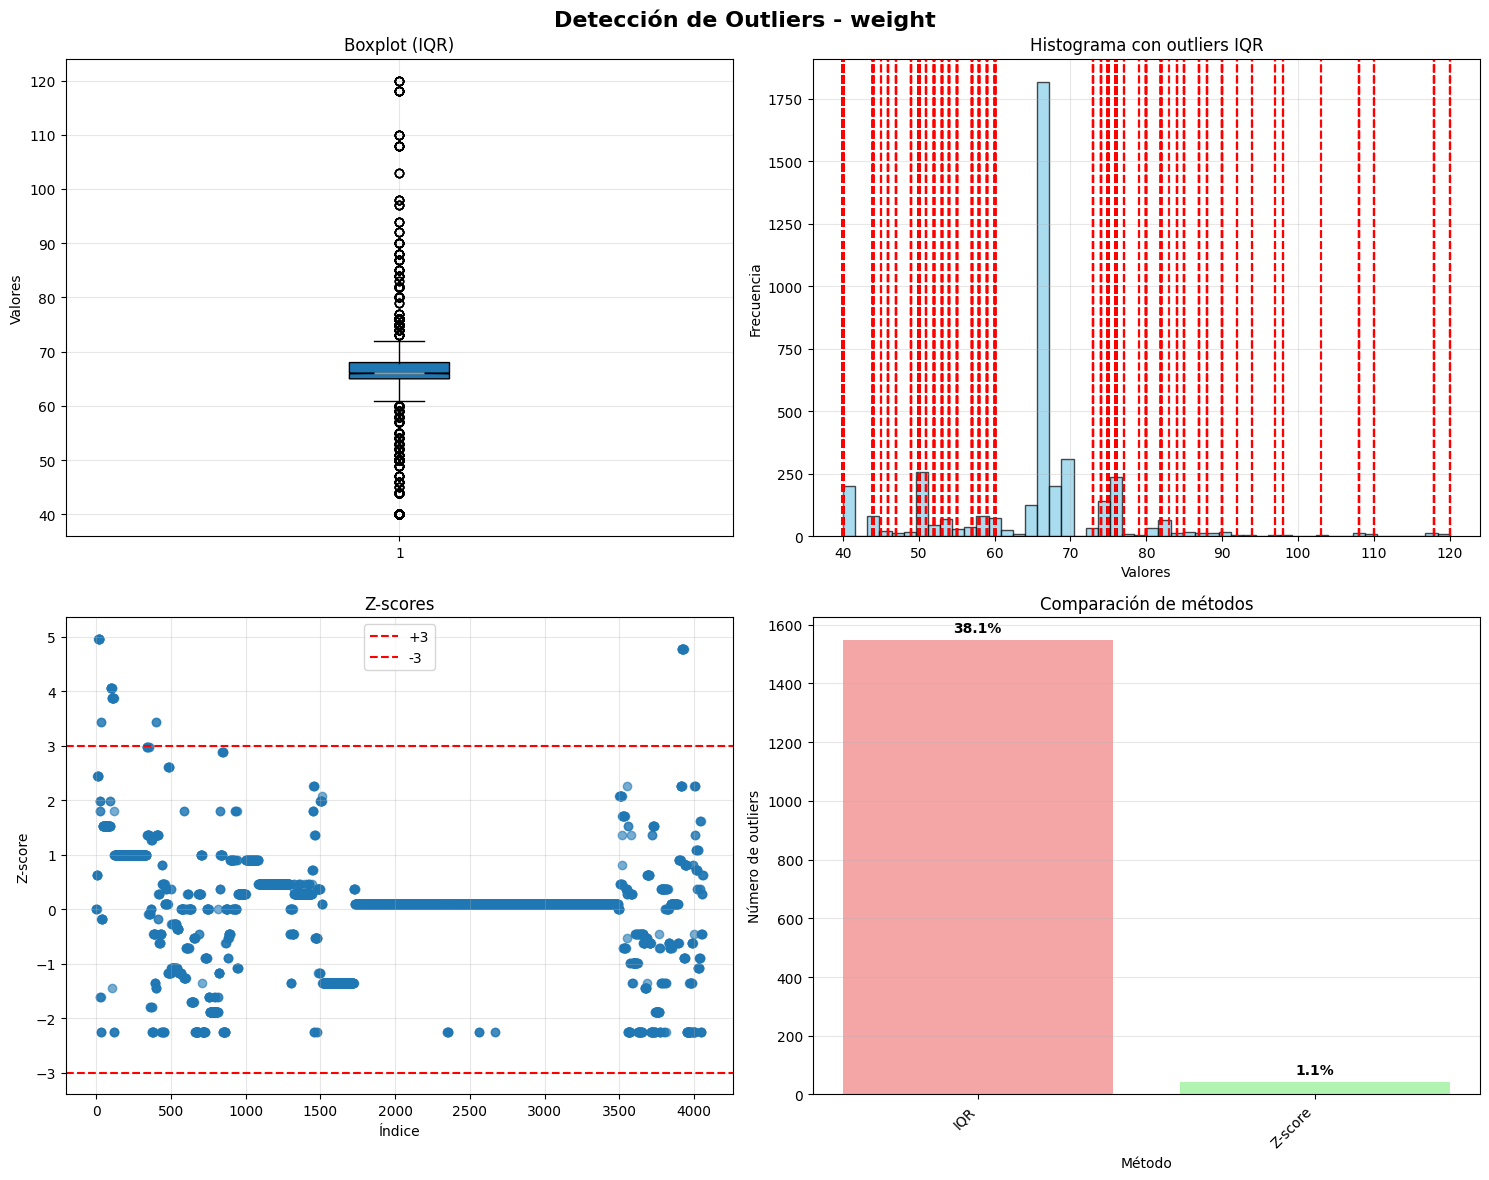

RESUMEN DE DETECCIÓN DE OUTLIERS - weight
IQR:
   • Outliers detectados: 1548
   • Porcentaje: 38.13%
   • Límite inferior: 60.50
   • Límite superior: 72.50

Z-score:
   • Outliers detectados: 44
   • Porcentaje: 1.08%
   • Umbral utilizado: 3

Outliers detectados por TODOS los métodos usados: 44
   Índices: [15, 16, 17, 18, 19, 20, 21, 22, 35, 36, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 110, 111, 112, 113, 114, 115, 116, 117, 402, 403, 3919, 3920, 3921, 3922, 3923, 3924, 3925, 3926, 3927, 3928, 3929, 3930]
   Valores: [np.int64(120), np.int64(120), np.int64(120), np.int64(120), np.int64(120), np.int64(120), np.int64(120), np.int64(120), np.int64(103), np.int64(103), np.int64(110), np.int64(110), np.int64(110), np.int64(110), np.int64(110), np.int64(110), np.int64(110), np.int64(110), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int64(108), np.int

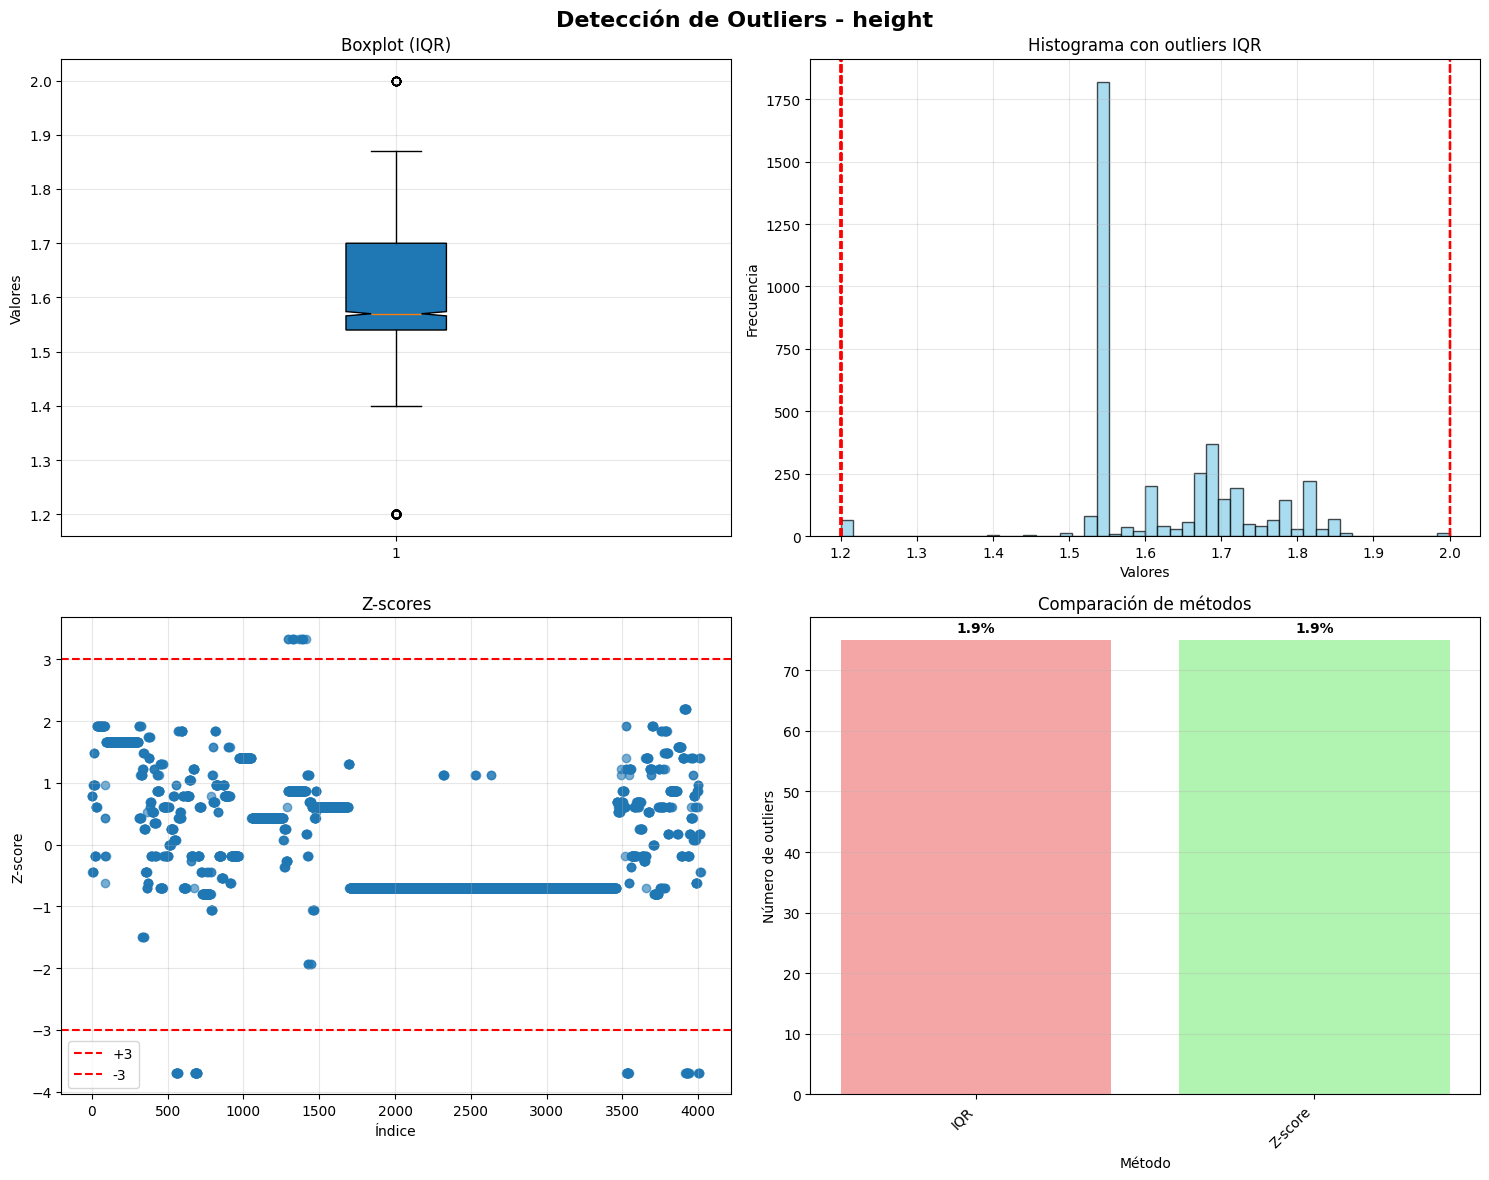

RESUMEN DE DETECCIÓN DE OUTLIERS - height
IQR:
   • Outliers detectados: 75
   • Porcentaje: 1.87%
   • Límite inferior: 1.30
   • Límite superior: 1.94

Z-score:
   • Outliers detectados: 75
   • Porcentaje: 1.87%
   • Umbral utilizado: 3

Outliers detectados por TODOS los métodos usados: 75
   Índices: [587, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 1323, 1324, 1355, 1356, 1357, 1368, 1399, 1410, 1421, 1422, 1423, 1444, 3558, 3559, 3560, 3561, 3562, 3563, 3564, 3565, 3566, 3567, 3568, 3569, 3570, 3571, 3572, 3958, 3964, 3965, 3966, 3967, 3968, 3969, 3971, 3972, 3974, 3977, 3980, 3981, 4045, 4046, 4047, 4048]
   Valores: [np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.float64(1.2), np.flo

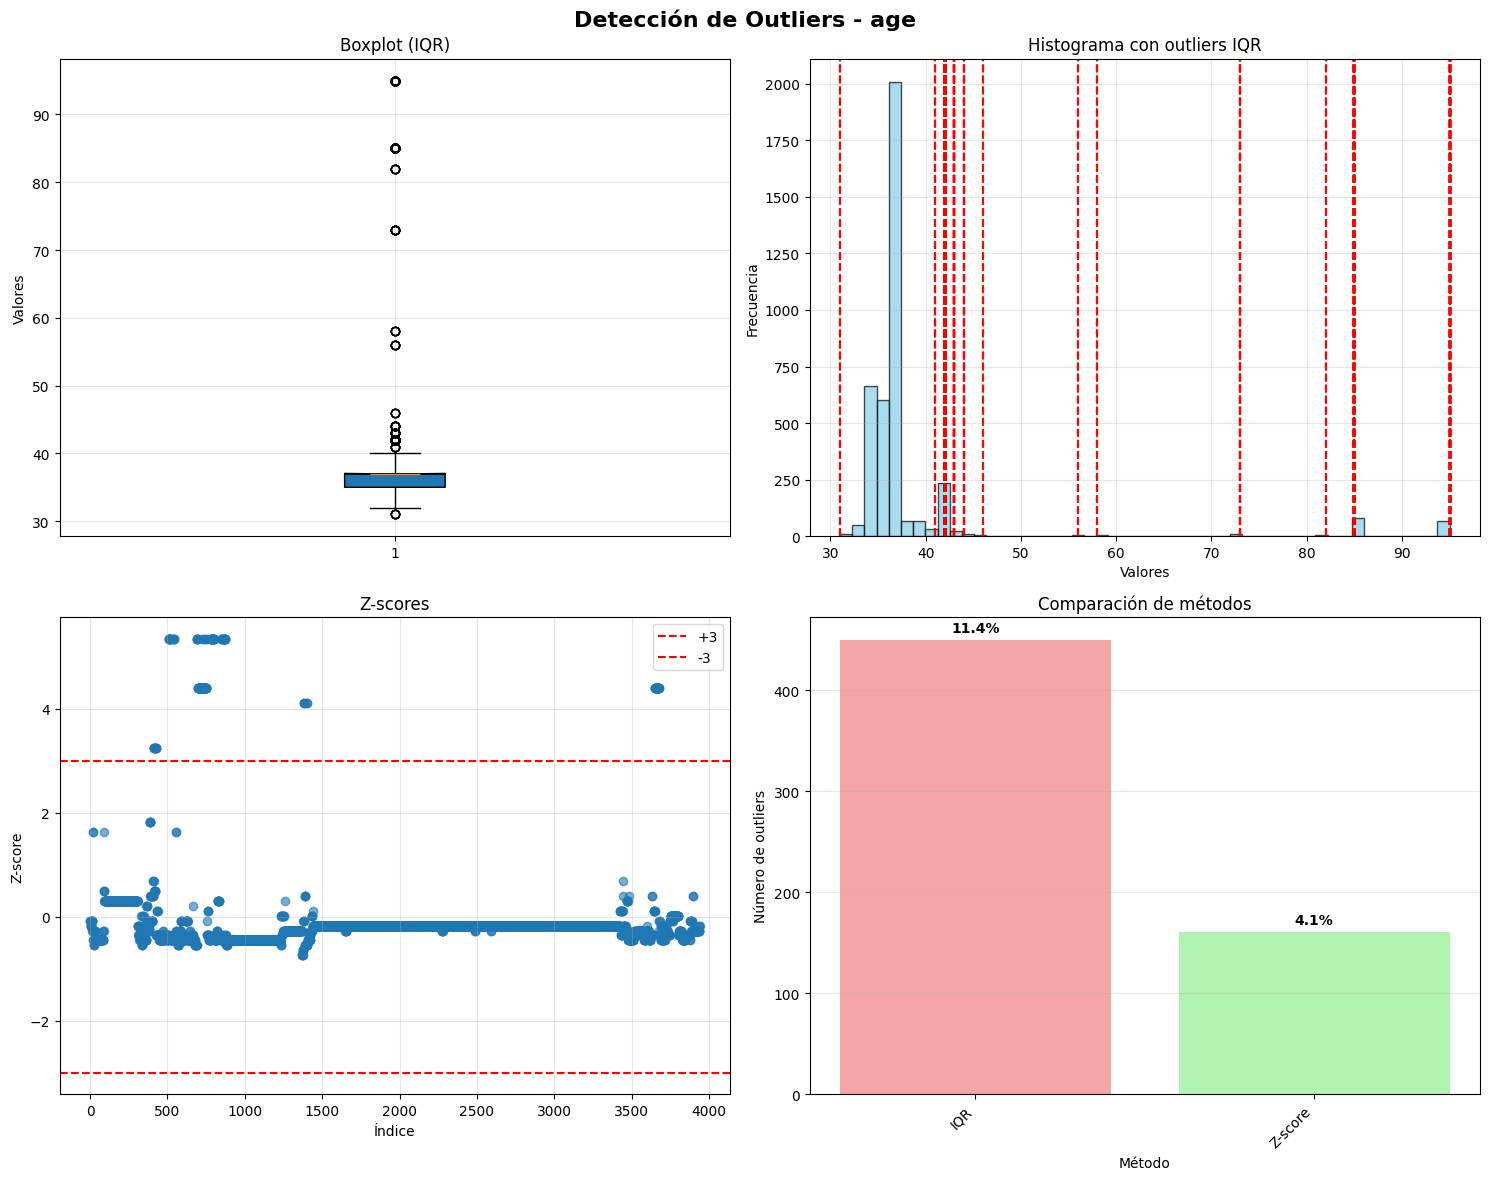

RESUMEN DE DETECCIÓN DE OUTLIERS - age
IQR:
   • Outliers detectados: 450
   • Porcentaje: 11.42%
   • Límite inferior: 32.00
   • Límite superior: 40.00

Z-score:
   • Outliers detectados: 161
   • Porcentaje: 4.09%
   • Umbral utilizado: 3

Outliers detectados por TODOS los métodos usados: 161
   Índices: [443, 444, 445, 446, 447, 450, 455, 456, 457, 458, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 569, 570, 572, 573, 576, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 780, 781, 782, 783, 784, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 818, 844, 845, 846, 847, 848, 849, 850, 851, 852, 853, 854, 855, 856, 857, 858, 859, 860, 861, 862, 863, 864, 912, 913, 914, 916, 917, 920, 924, 926, 927, 930, 931, 933, 934, 935, 936, 937, 938, 1458, 1459, 1460, 1479, 1480, 3741, 3742, 374

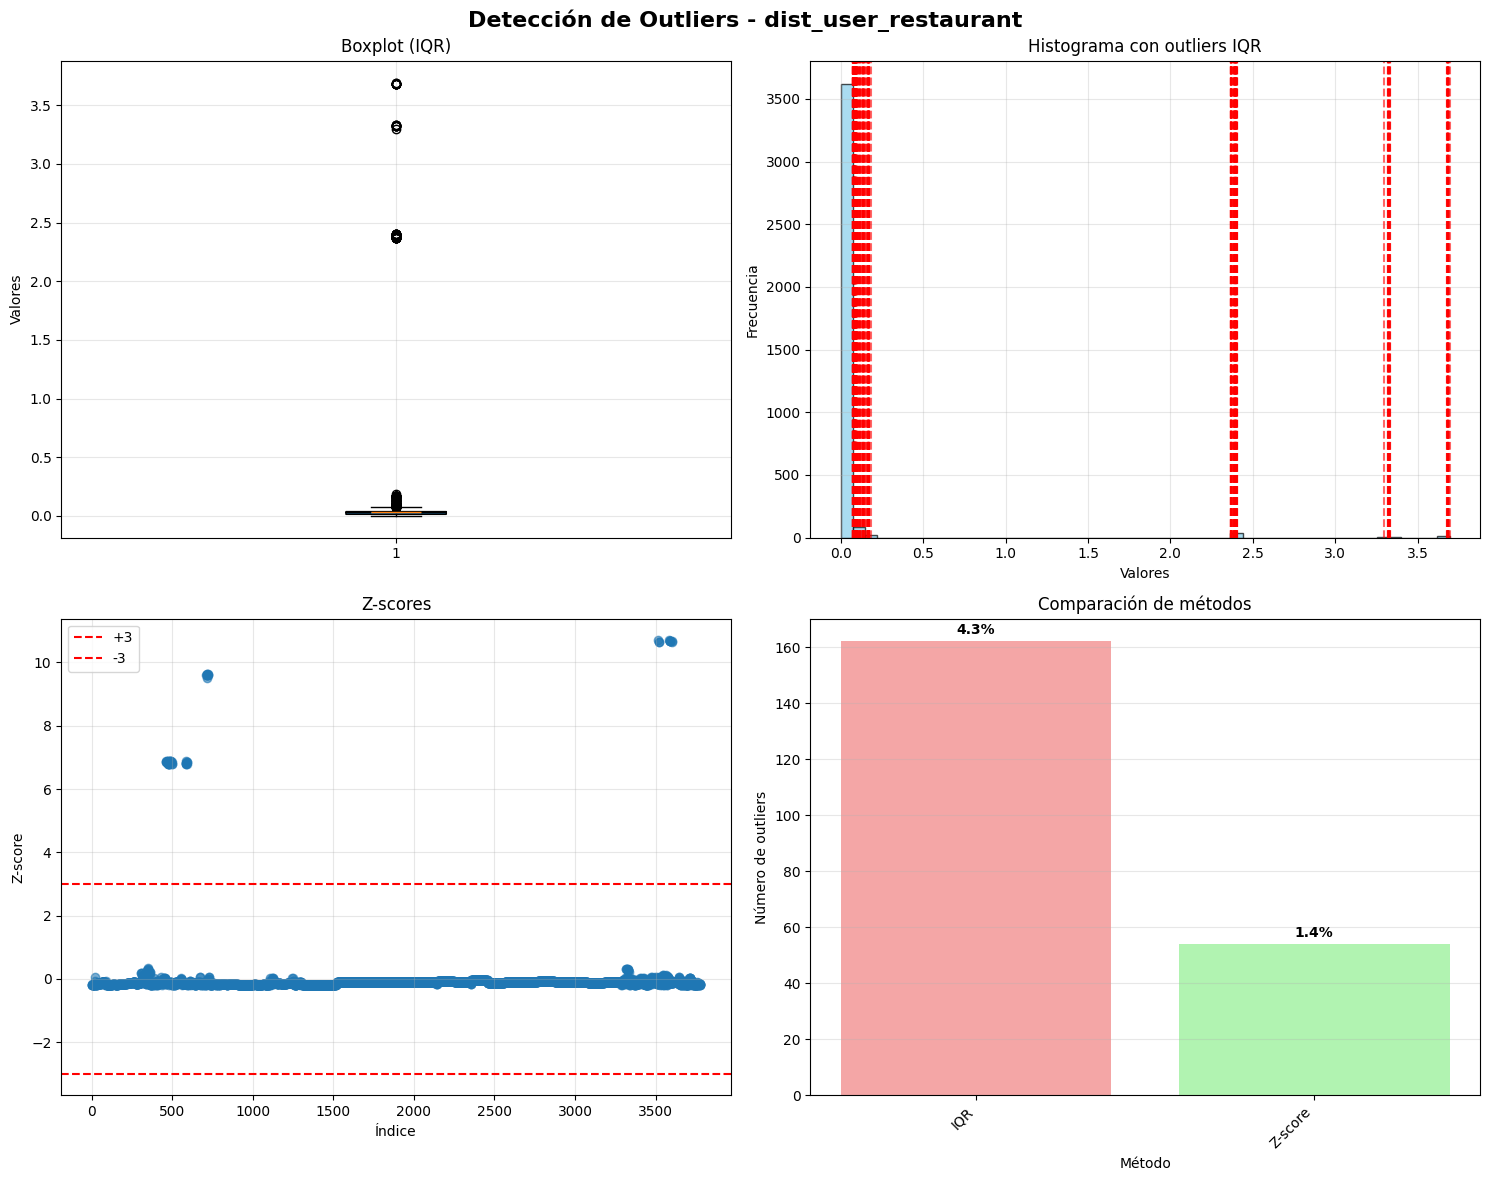

RESUMEN DE DETECCIÓN DE OUTLIERS - dist_user_restaurant
IQR:
   • Outliers detectados: 162
   • Porcentaje: 4.29%
   • Límite inferior: -0.02
   • Límite superior: 0.07

Z-score:
   • Outliers detectados: 54
   • Porcentaje: 1.43%
   • Umbral utilizado: 3

Outliers detectados por TODOS los métodos usados: 54
   Índices: [502, 503, 506, 507, 508, 509, 511, 512, 513, 514, 515, 516, 521, 522, 523, 524, 525, 526, 531, 532, 537, 538, 539, 540, 653, 654, 655, 656, 657, 658, 659, 660, 661, 887, 888, 889, 890, 891, 892, 893, 894, 895, 896, 3769, 3770, 3771, 3837, 3838, 3839, 3840, 3841, 3842, 3855, 3856]
   Valores: [np.float64(2.3915239576755223), np.float64(2.3915239576755223), np.float64(2.3972168446304583), np.float64(2.3972168446304583), np.float64(2.39345517453096), np.float64(2.39345517453096), np.float64(2.392342286013856), np.float64(2.392342286013856), np.float64(2.4008873835157285), np.float64(2.4008873835157285), np.float64(2.3666488885884656), np.float64(2.3666488885884656), np.fl

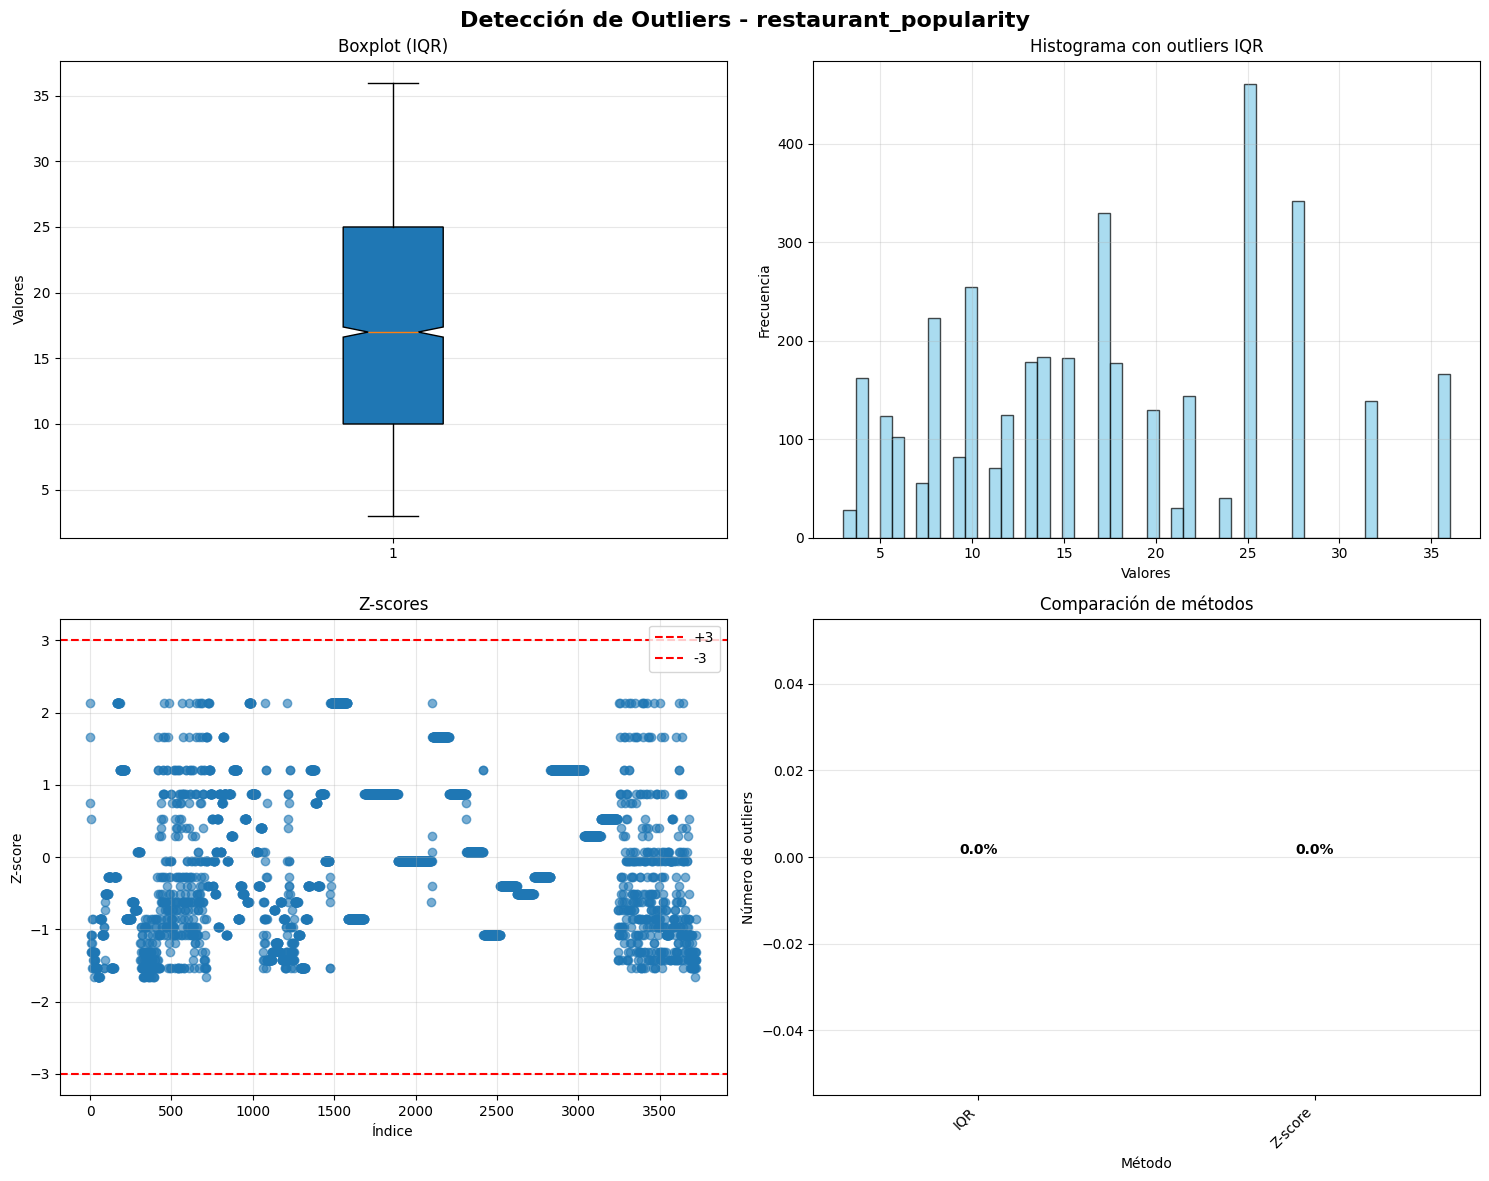

RESUMEN DE DETECCIÓN DE OUTLIERS - restaurant_popularity
IQR:
   • Outliers detectados: 0
   • Porcentaje: 0.00%
   • Límite inferior: -12.50
   • Límite superior: 47.50

Z-score:
   • Outliers detectados: 0
   • Porcentaje: 0.00%
   • Umbral utilizado: 3

Outliers detectados por TODOS los métodos usados: 0


In [86]:
# para cada variable float64, aplicar la deteccion de outliers
df_outliers = df_nulos.copy()

# Diccionario para guardar los resultados
outliers_dict = {}

for column in continuas:

    series = df_outliers[column]

    # Detectar outliers para la columna actual
    detalles = detect_outliers(
        data=series,
        methods=['iqr', 'zscore'],
        z_threshold=3,
        iqr_factor=1.5,
        plot=True,
        return_details=True
    )

    # Extraer cada parte
    results = detalles["results"]
    outlier_indices = detalles["indices"]
    common_sorted = detalles["common"]

    # Guardar resultados
    outliers_dict[column] = {
        "results": results,
        "indices": outlier_indices,
        "common": common_sorted
    }

    # ELIMINAR LOS OUTLIERS COMUNES DE ESTA COLUMNA EN df_outliers
    df_outliers = df_outliers.drop(index=common_sorted, errors="ignore")


In [87]:
df_outliers.shape[0]/df_nulos.shape[0]*100

91.77339901477832

In [88]:
df_outliers.to_csv("datos/data_analitica_sin_nulos_ni_outliers.csv", index=False)

## Detección de variables altamente correlacionadas. Remueva solo aquellas con correlación 1 en valor absoluto

18


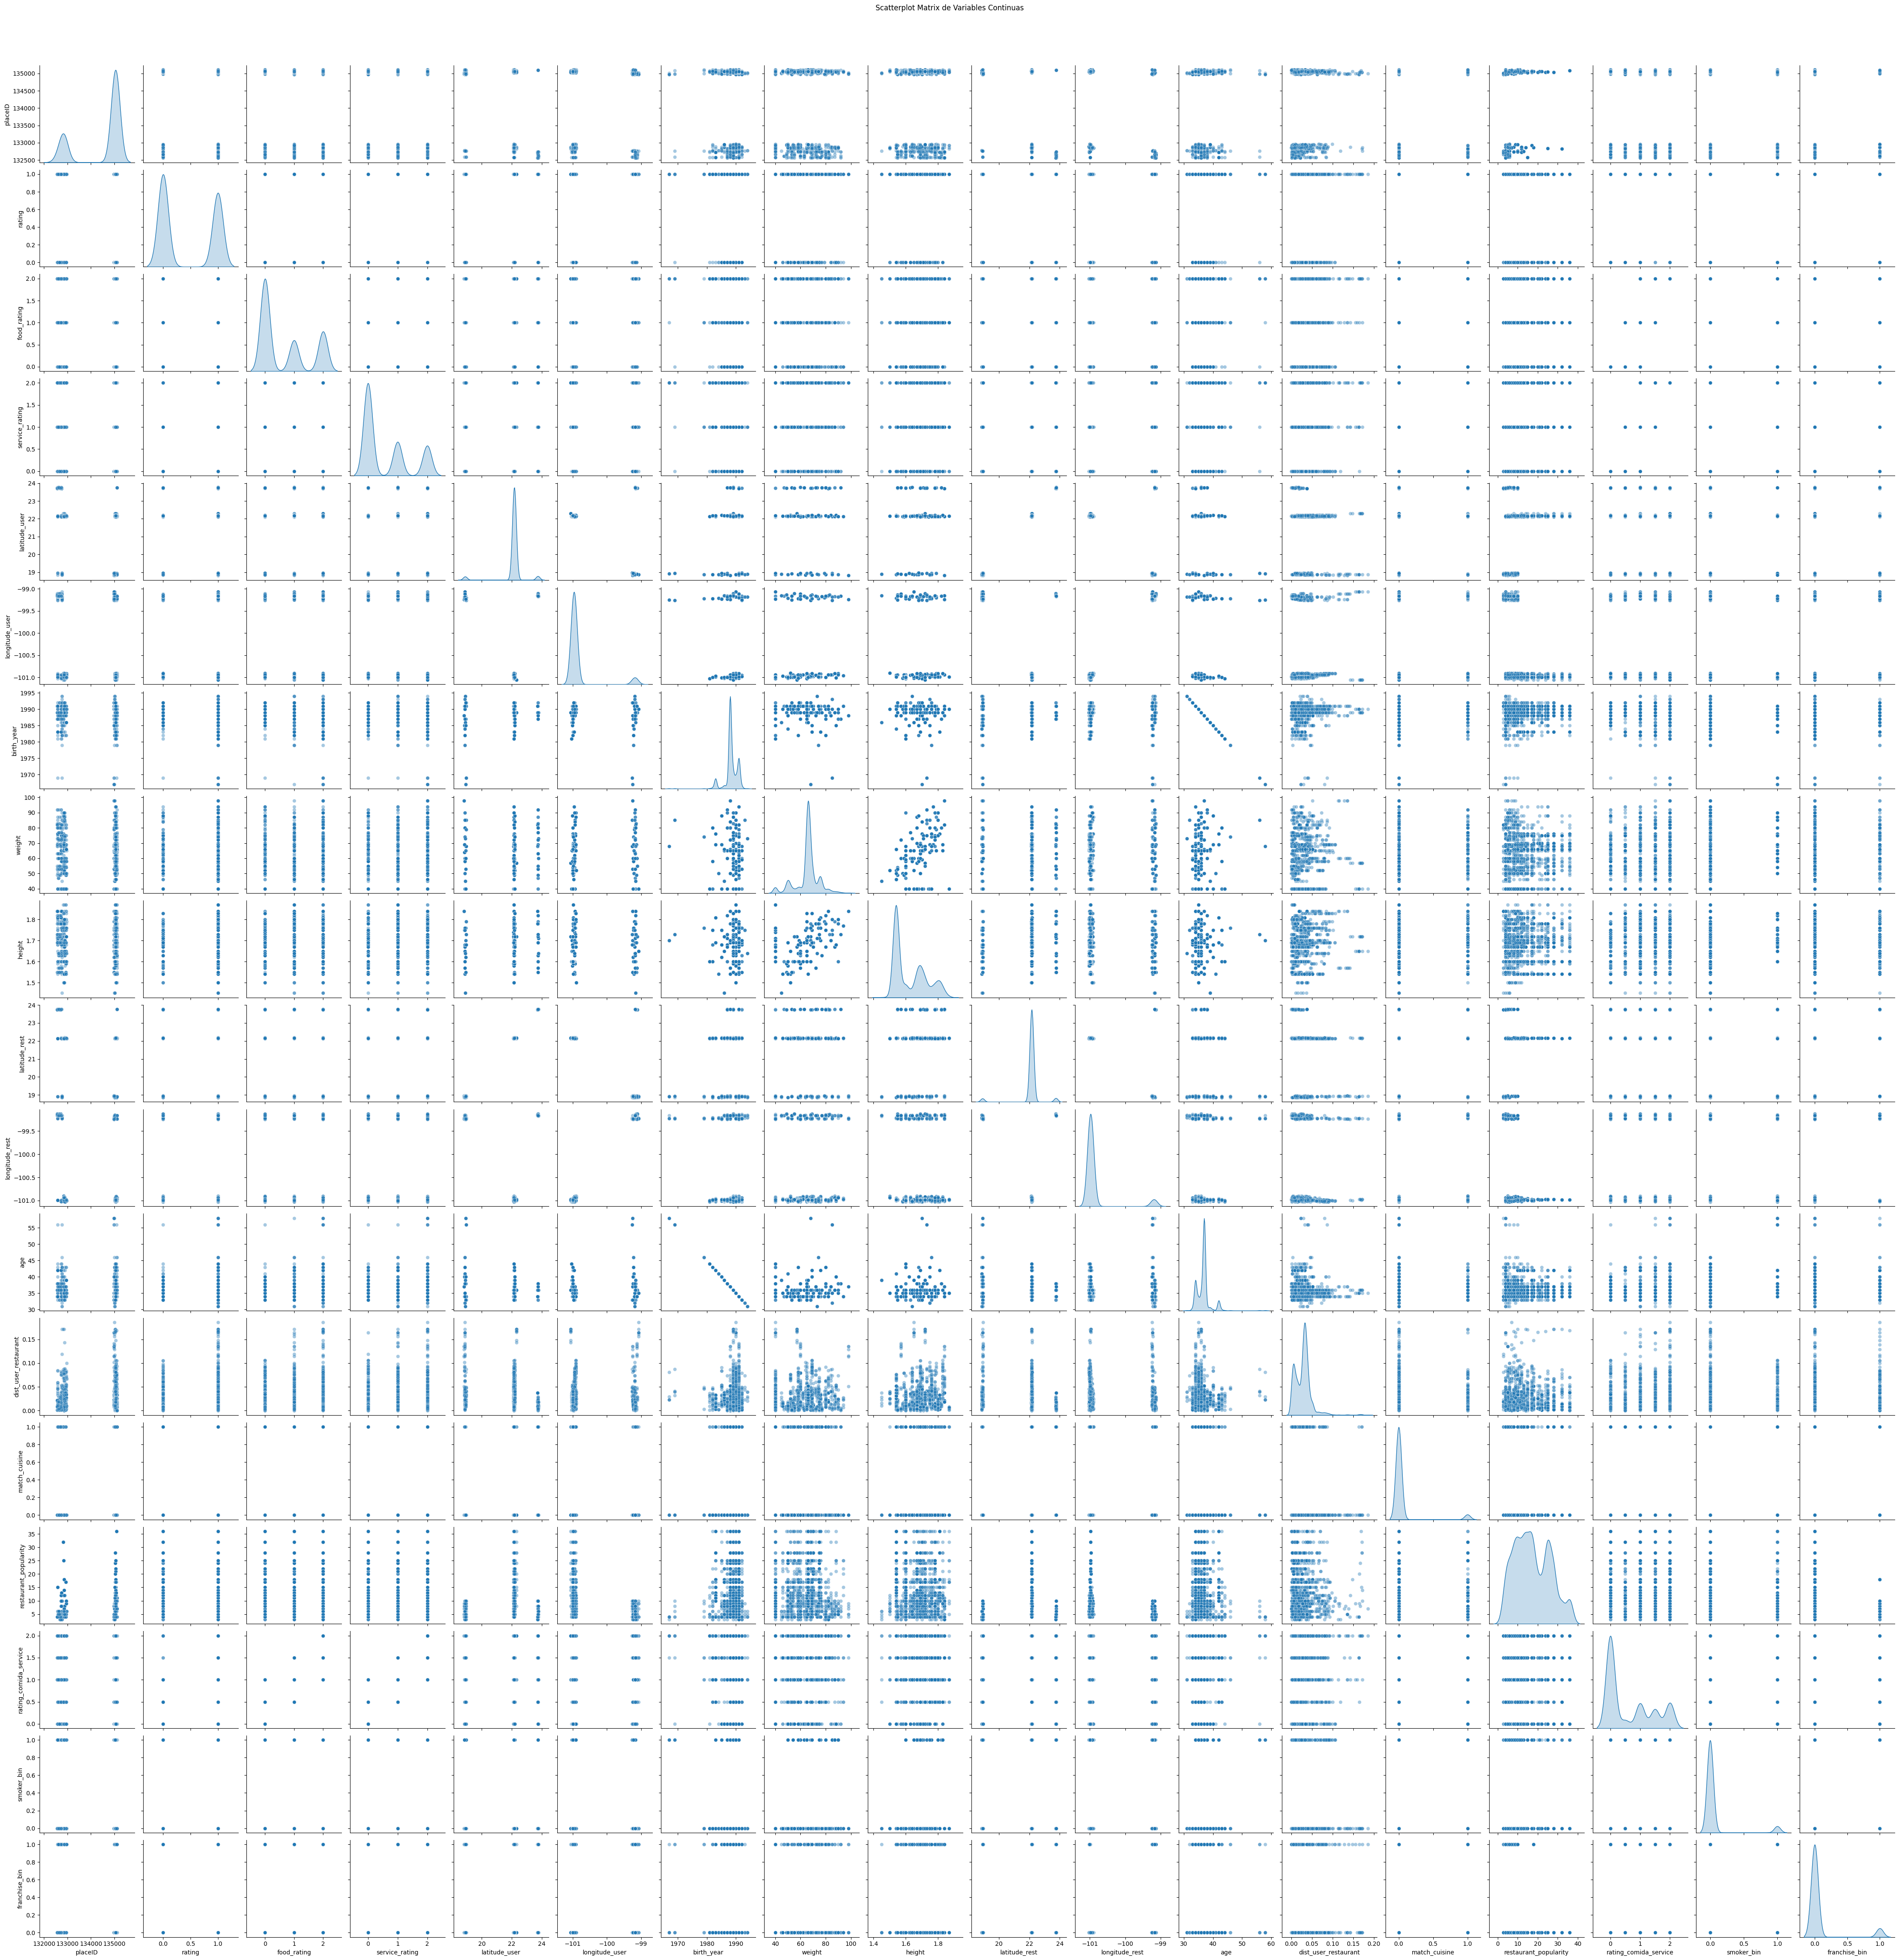

In [89]:
# Filtrar solo esas columnas, que son float64
cols_float = df_outliers.select_dtypes(include=["number"]).columns
data_float = df_outliers[cols_float]
print(len(cols_float))
# Crear matriz de scatterplots
sns.pairplot(data_float, diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle("Scatterplot Matrix de Variables Continuas", y=1.02)
plt.show()

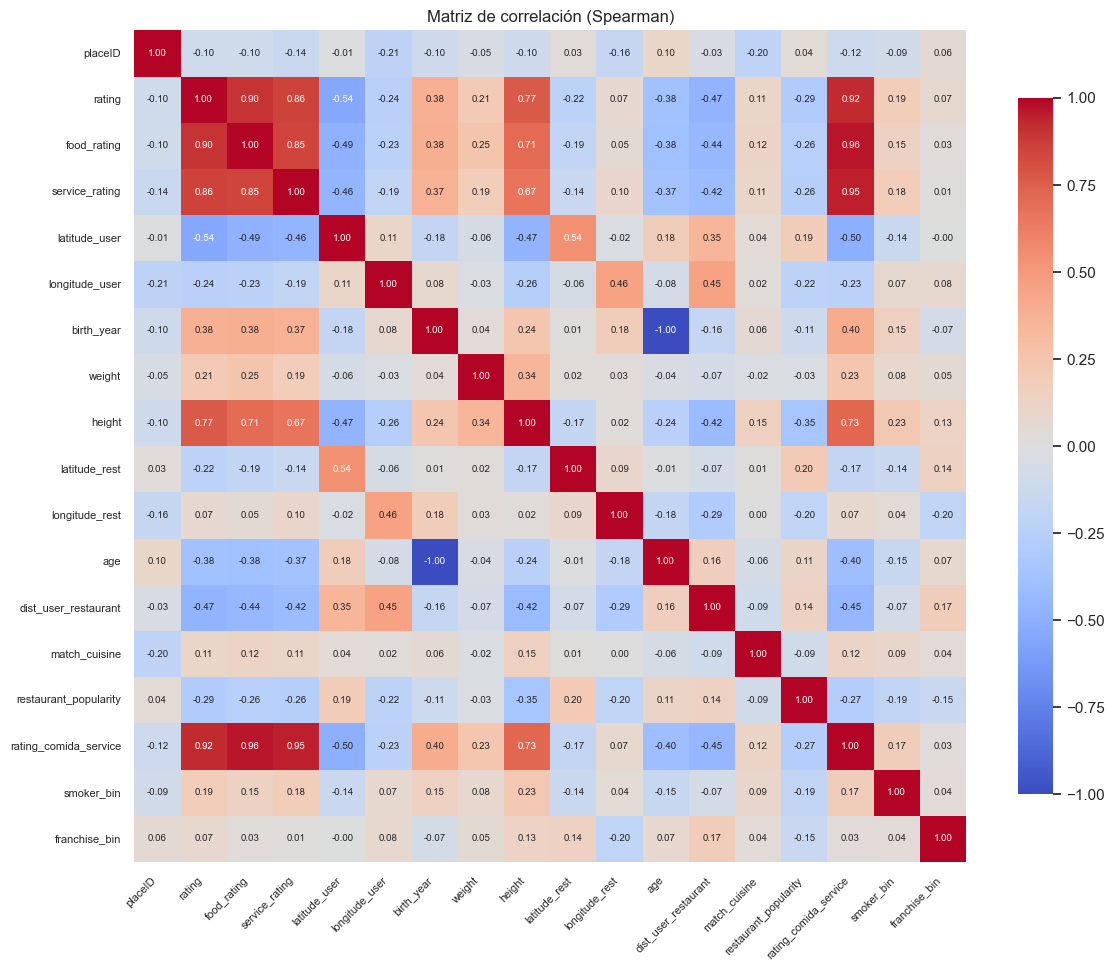

In [90]:
plot_heatmap(df_outliers, True)

In [91]:
# Obtener matriz de correlaciones sin la diagonal (1.0)
corr_matrix = data_float.corr(method='spearman')

# Convertir a tabla larga
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Triangular superior sin diagonal
    .stack()  # convertir a pares (col1, col2)
    .reset_index()
)

corr_pairs.columns = ["var1", "var2", "correlation"]

# Ordenar por valor absoluto descendente
corr_pairs_sorted = corr_pairs.reindex(corr_pairs["correlation"].abs().sort_values(ascending=False).index)

# Mostrar las top correlaciones cercanas a 1
corr_pairs_sorted.head()

,var1,var2,correlation
91,birth_year,age,-1.000000
45,food_rating,rating_comida_service,0.964818
59,service_rating,rating_comida_service,0.949984
30,rating,rating_comida_service,0.922004
17,rating,food_rating,0.899265


In [92]:
# Eliminamos las variables con correlación perfecta, birth_year,latitude_user, longitude_user.      
df_outliers_multicolinealidad = df_outliers.drop(columns=['birth_year'])   

In [93]:
cols_num = df_outliers_multicolinealidad.select_dtypes(include=["number"]).columns
data_num = df_outliers[cols_num]

In [94]:
data_num.describe()

,placeID,rating,food_rating,service_rating,latitude_user,longitude_user,weight,height,latitude_rest,longitude_rest,age,dist_user_restaurant,match_cuisine,restaurant_popularity,rating_comida_service,smoker_bin,franchise_bin
count,3726.00000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000,3726.000000
mean,134482.10306,0.444444,0.676329,0.599302,22.107424,-100.829493,65.492485,1.626793,22.098685,-100.847870,36.681965,0.028301,0.050993,17.434246,0.637815,0.064949,0.086420
std,978.60992,0.496971,0.840206,0.789658,0.683963,0.465032,8.980774,0.099958,0.680590,0.467756,2.297716,0.020309,0.220013,8.728990,0.776929,0.246469,0.281021
min,132560.00000,0.000000,0.000000,0.000000,18.813348,-101.054680,40.000000,1.450000,18.859803,-101.028600,31.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,132954.00000,0.000000,0.000000,0.000000,22.150891,-100.977402,66.000000,1.540000,22.148665,-100.983092,35.000000,0.013458,0.000000,10.000000,0.000000,0.000000,0.000000
50%,135041.00000,0.000000,0.000000,0.000000,22.170396,-100.949936,66.000000,1.580000,22.151060,-100.977412,37.000000,0.029590,0.000000,17.000000,0.000000,0.000000,0.000000
75%,135058.00000,1.000000,1.000000,1.000000,22.170396,-100.949936,68.000000,1.700000,22.156469,-100.973486,37.000000,0.037197,0.000000,25.000000,1.500000,0.000000,0.000000
max,135109.00000,1.000000,2.000000,2.000000,23.771030,-99.067106,98.000000,1.870000,23.760268,-99.126506,58.000000,0.185533,1.000000,36.000000,2.000000,1.000000,1.000000


# Reducción de dimensiones

Aplique las siguientes técnicas al conjunto de datos resultante del punto anterior. Dichos procesos no deben de ejecutarse de manera secuencial, es decir, no dependen uno de otro. 

– Utilizando PCA, reduzca el conjunto de datos a 2 dimensiones y realice una visualización del conjunto. 

– Utilizando Clustering de variables, remueva multicolinealidad. 

– Seleccione las mejores variables utilizando SelectKBest. 

– Seleccione las mejores variables utilizando WoE y IV, solo si aplica. 

Los últimos dos puntos solo aplican si se construyó una variable objetivo. 


## PCA

Eliminamos las varibales que no tienen orden.

In [95]:
X = data_num.drop(columns=['rating', 'food_rating', 'service_rating', 'service_rating','smoker_bin', 'franchise_bin','match_cuisine', 'placeID'])

Se utilizo StandardScaler, ya que PCA pide estandarizacion de variables, notando que se hizo el ejercicio con RobustScaler, lo cual nos dio una varianza explicada acumulada del 99% con 2 variables, pero nos quedamos con StandardScaler ya que es el que se vio en la clase mantiene la varianza, quitando la opcion de MinMaxScaler ya que no es valido teoricamente..

In [96]:
# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [97]:
df_num_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_num_scaled.describe()

,latitude_user,longitude_user,weight,height,latitude_rest,longitude_rest,age,dist_user_restaurant,restaurant_popularity,rating_comida_service
count,3.726000e+03,3.726000e+03,3.726000e+03,3.726000e+03,3.726000e+03,3.726000e+03,3.726000e+03,3726.000000,3.726000e+03,3.726000e+03
mean,-4.271647e-15,2.218205e-14,6.102353e-16,2.196847e-15,-1.937497e-15,1.273866e-14,2.669779e-17,0.000000,1.144191e-16,1.525588e-16
std,1.000134e+00,1.000134e+00,1.000134e+00,1.000134e+00,1.000134e+00,1.000134e+00,1.000134e+00,1.000134,1.000134e+00,1.000134e+00
min,-4.816808e+00,-4.843046e-01,-2.838943e+00,-1.768902e+00,-4.759570e+00,-3.864279e-01,-2.473207e+00,-1.393704,-1.653821e+00,-8.210540e-01
25%,6.355949e-02,-3.181044e-01,5.651883e-02,-8.684063e-01,7.344602e-02,-2.891248e-01,-7.321142e-01,-0.730945,-8.517874e-01,-8.210540e-01
50%,9.208095e-02,-2.590339e-01,5.651883e-02,-4.681859e-01,7.696549e-02,-2.769800e-01,1.384323e-01,0.063473,-4.975422e-02,-8.210540e-01
75%,9.208095e-02,-2.590339e-01,2.792467e-01,7.324753e-01,8.491407e-02,-2.685857e-01,1.384323e-01,0.438084,8.668551e-01,1.109883e+00
max,2.432630e+00,3.790328e+00,3.620164e+00,2.433412e+00,2.441713e+00,3.680543e+00,9.279171e+00,7.743081,2.127193e+00,1.753528e+00


In [98]:
# PCA con 2 componentes
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print("Varianza explicada con 2 componentes:", pca2.explained_variance_ratio_.cumsum())

Varianza explicada con 2 componentes: [0.28864144 0.4967002 ]


Alcanzamos un 46% de varinza explicada lo cual no es muy optimo ya que teoricamente necesitamos un 90%

In [99]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=X.columns,
    columns=['PC1','PC2']
)

In [100]:
important_loadings = loadings[(loadings.abs() >= .32).any(axis=1)]
important_loadings

,PC1,PC2
latitude_user,-0.381117,0.441061
longitude_user,0.490247,0.085739
height,0.237073,0.451143
latitude_rest,-0.375815,0.448338
longitude_rest,0.491477,0.100772
dist_user_restaurant,0.066954,-0.369470
rating_comida_service,0.256749,0.394206


Las variables que mas aportan para PCA son `latitude_user`, `longitude_user`, `latitude_rest`, `longitude_rest`, `height`, `dist_user_restaurant`

In [101]:
Xp2 = pd.DataFrame(index=X.index, data=X_pca2,
                   columns=['PC1','PC2'])

In [102]:
Xp2["rating"] = data_float["rating"]

In [103]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=Xp2["PC1"],
        y=Xp2["PC2"],
        mode="markers",
        marker=dict(
            size=6,
            color=Xp2["rating"],   # Color según la variable objetivo
            colorscale="Viridis",
            showscale=True         # Mostrar barra de colores
        ),
        text=Xp2["rating"],         # Hover info
        hovertemplate=(
            "PC1: %{x}<br>" +
            "PC2: %{y}<br>" +
            "Objetivo: %{text}<extra></extra>"
        )
    )
)

fig.update_layout(
    title="PCA con 2 componentes (coloreado por la variable objetivo)",
    xaxis_title="Componente Principal 1",
    yaxis_title="Componente Principal 2",
    width=900,
    height=650
)

# fig.show(renderer="browser") # Para graficarlo en el navegador
fig

El gráfico de PCA utilizando StandardScaler muestra tres agrupamientos o clusters bien definidos dentro del espacio proyectado por los dos primeros componentes principales.

Esto indica la presencia de patrones en las variables numéricas.

Aunque la variable objetivo no presenta una separación perfecta entre clases, sí se observan tendencias diferenciadas dentro de cada cluster. (Y que los clusters de la derecha contienen mas elemenos de la clase 1)

## VarClusHi - Análisis de Multicolinealidad

Implementar VarClusHi para identificar grupos de variables altamente correlacionadas.


Esto es clave porque la multicolinealidad dificulta la interpretación de modelos y puede generar inestabilidad. El método agrupa variables en clústeres y evalúa qué variable representa mejor a cada grupo.


In [104]:
vc = VarClusHi(df_num_scaled, maxeigval2=1.0)
vc.varclus()

# Resultados de R^2
print("Tabla de R^2 por variable")
vc.rsquare

Tabla de R^2 por variable


,Cluster,Variable,RS_Own,RS_NC,RS_Ratio
0,0,longitude_user,0.938327,0.067918,0.066167
1,0,longitude_rest,0.939224,0.063407,0.064890
2,0,restaurant_popularity,0.351192,0.076615,0.702640
3,1,latitude_user,0.947408,0.071599,0.056647
4,1,latitude_rest,0.950400,0.066765,0.053149
5,1,age,0.084494,0.000043,0.915545
6,1,dist_user_restaurant,0.169259,0.055149,0.879229
7,2,weight,0.142811,0.009770,0.865647
8,2,height,0.830691,0.065145,0.181108
9,2,rating_comida_service,0.741788,0.063992,0.275865


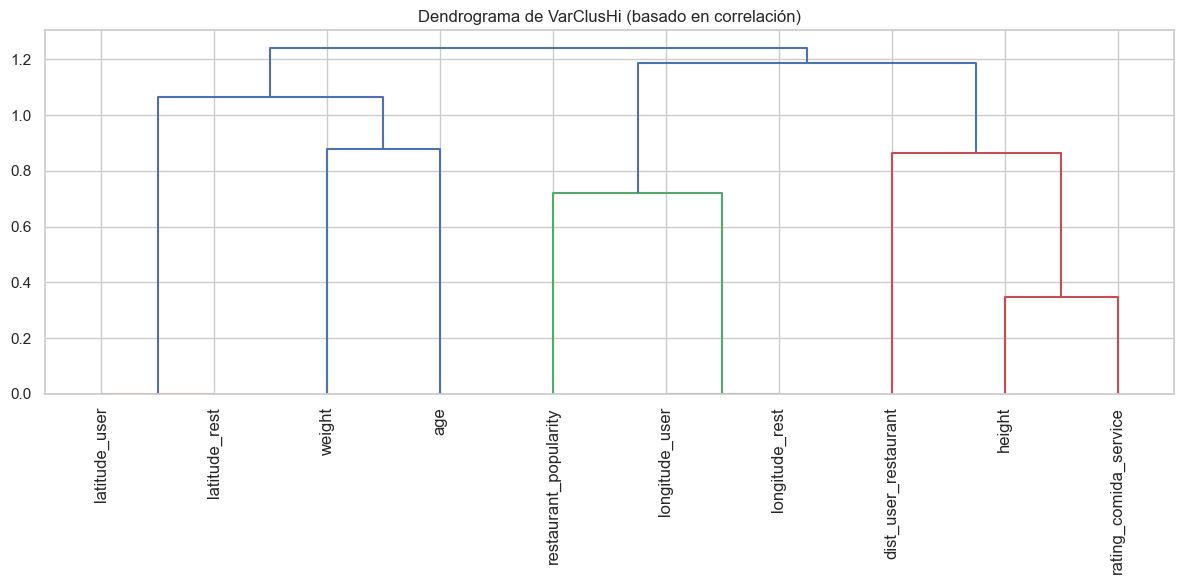

In [105]:
# Matriz de correlaciones
corr = df_num_scaled.corr().values

# Convertir correlación a distancia: d = 1 - |corr|
dist = 1 - np.abs(corr)

# Distanciás condensada para linkage
dist_cond = squareform(dist)

# linkage para cluster jerárquico
Z = linkage(dist_cond, method='ward')

# gráfica
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df_num_scaled.columns, leaf_rotation=90)
plt.title("Dendrograma de VarClusHi (basado en correlación)")
plt.tight_layout()
plt.show()


El análisis VarClusHi permitió identificar tres agrupamientos principales de variables.
Los clusters 0 y 1 están dominados por las coordenadas geográficas (latitud y longitud), mostrando R² propios muy altos (> 0.93), lo que confirma que estos atributos explican una gran parte de la variabilidad interna del conjunto de datos.

En contraste, variables como age y dist_user_restaurant presentan valores bajos de R² propio y ratios inferiores a 1, lo cual indica que no están adecuadamente representadas en dichos clusters y podrían reubicarse o analizarse de forma separada.

El cluster 2 agrupa variables antropométricas como height y weight, junto con ratings del restaurante. Aunque height muestra buena cohesión (RS_Own = 0.83), otras variables del cluster presentan relaciones menos fuertes, lo que sugiere una estructura menos definida

| Métrica                       | Significa                                                                                             |
| ----------------------------- | ----------------------------------------------------------------------------------------------------- |
| **RS_Own**                    | Qué tan bien la variable se explica con su propio cluster → **mientras mayor, mejor**                 |
| **RS_NC**                     | Qué tanto se explica por el *cluster que no es el suyo* → **mientras menor, mejor**                   |
| **RS_Ratio = RS_NC / RS_Own** | Si es **bajo** → variable bien ubicada. Si es **alto** → variable redundante, colineal o mal agrupada |


Variables a eliminar

| Variable                  | Motivo                                             |
| ------------------------- | -------------------------------------------------- |
| **restaurant_popularity** | RS_Ratio = 0.702 → muy mal explicada               |
| **age**                   | RS_Ratio = 0.915 → no pertenece al cluster → ruido |
| **dist_user_restaurant**  | RS_Ratio = 0.879 → multicolineal fuerte            |
| **weight**                | RS_Ratio = 0.865 → contribución débil/ruido        |


## Poder Predictivo con SelectKBest

In [106]:
df_outliers_multicolinealidad.columns

Index(['userID', 'placeID', 'rating', 'food_rating', 'service_rating',
       'latitude_user', 'longitude_user', 'smoker', 'drink_level',
       'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos',
       'interest', 'personality', 'religion', 'activity', 'color', 'weight',
       'budget', 'height', 'latitude_rest', 'longitude_rest', 'the_geom_meter',
       'name', 'address', 'city', 'state', 'zip', 'alcohol', 'smoking_area',
       'dress_code', 'accessibility', 'price', 'Rambience', 'franchise',
       'area', 'Rcuisine', 'Rcuisine_restcuisine', 'age',
       'dist_user_restaurant', 'match_cuisine', 'restaurant_popularity',
       'rating_comida_service', 'preference_ambience_match', 'smoker_bin',
       'franchise_bin'],
      dtype='object')

In [107]:
#Sin Escalar
X = df_outliers_multicolinealidad.drop(columns=['rating_comida_service', 'zip', 'address', 'name', 'the_geom_meter', 'userID', 'placeID', 'rating', 'food_rating', 'service_rating', 'service_rating','smoker_bin', 'franchise_bin'])
y = df_outliers_multicolinealidad['rating']

In [108]:
# La funcion solo codifica las variables categoricas ma no escala las viariables
data_poder, scores, vars_seleccionadas, fig = poder_predictivo(X=X,y=y,num_k=5)

In [109]:
data_poder.head(1)

,cat__hijos_independent,cat__hijos_kids,cat__personality_hunter-ostentatious,cat__color_purple,num__height
0,0.0,1.0,0.0,0.0,1.71


In [110]:
fig

Nota importante: las variables categoricas fueron convertidas a variables dummys donde cada categorica considera solo explica uno de los casos de la variable categorica.

Dado que la variable `color (purple)` `hijos (kids, independent)`, `height`, `personality (hunter-ostentatious)`, `trasport (on foot)` e `interest (variety)` son variables de probabilidad y estimación de la calificación en funcion del conjunto de datos total. Se puede siscutir si tomar a color predilecto por el ususario para la prediccion de la calificacón, se dejo ya que los restaurantes podrian tener diseños con algun color especifico. Si el usuario tiene hijos, personalidad, el transporte que usa y los intereses son factores que esperabamos que influyeran para la clificacion ototgada al final.

### Transformación Entropica con IV y WoE

Implementar una función para calcular IV y WoE para las variables categóricas del conjunto de datos.

El cálculo de WoE y IV permite evaluar el poder predictivo de variables categóricas. WoE reorganiza las categorías de acuerdo con su nivel de riesgo y IV resume cuánta información aporta la variable.


In [111]:
colum_categoricas

['rating',
 'food_rating',
 'service_rating',
 'smoker',
 'drink_level',
 'dress_preference',
 'ambience',
 'transport',
 'marital_status',
 'hijos',
 'interest',
 'personality',
 'religion',
 'activity',
 'color',
 'budget',
 'city',
 'state',
 'alcohol',
 'smoking_area',
 'dress_code',
 'accessibility',
 'price',
 'Rambience',
 'franchise',
 'area',
 'match_cuisine',
 'rating_comida_service',
 'preference_ambience_match',
 'smoker_bin',
 'franchise_bin']

In [112]:
var_cat = [
 'smoker',
 'drink_level',
 'dress_preference',
 'ambience',
 'transport',
 'marital_status',
 'hijos',
 'interest',
 'personality',
 'religion',
 'activity',
 'color',
 'budget',
 'city',
 'state',
 'alcohol',
 'smoking_area',
 'dress_code',
 'accessibility',
 'price',
 'Rambience',
 'franchise',
 'area',
 'match_cuisine',
 'preference_ambience_match']

In [113]:
data_con_nan[var_cat].isnull().sum().sort_values(ascending=False).head(2)

smoking_area    2404
interest         349
dtype: int64

In [114]:
indices_clean = df_outliers.index
data_semi_clean= data_con_nan.loc[indices_clean]

In [115]:
data_semi_clean = data_semi_clean[var_cat + ['rating']].copy()

In [116]:
# reemplazar los NaN en las variables categoricas por 'Missing'
data_semi_clean[var_cat] = data_semi_clean[var_cat].fillna('Missing')

In [117]:
for variable in var_cat:
    tabla, iv = calcular_woe_iv(data_semi_clean, variable=variable, target='rating')
    print(f'IV de la variable {variable}: {iv:.2f}')
    display(tabla)

IV de la variable smoker: 0.16


,total,malos,buenos,dist_buenos,dist_malos,WoE,IV_bin
smoker,,,,,,,
false,3484,1463,2021,0.976329,0.883454,0.09996,0.009284
true,242,193,49,0.023671,0.116546,-1.59398,0.148040


IV de la variable drink_level: 1.60


,total,malos,buenos,dist_buenos,dist_malos,WoE,IV_bin
drink_level,,,,,,,
abstemious,560,508,52,0.025121,0.306763,-2.502345,0.704767
casual drinker,2713,743,1970,0.951691,0.448671,0.751948,0.378244
social drinker,453,405,48,0.023188,0.244565,-2.355791,0.521517


IV de la variable dress_preference: 1.47


...

,total,malos,buenos,dist_buenos,dist_malos,WoE,IV_bin
area,,,,,,,
closed,3348,1530,1818,0.878261,0.923913,-0.050674,0.002313
open,378,126,252,0.121739,0.076087,0.469999,0.021456


IV de la variable match_cuisine: 0.05


,total,malos,buenos,dist_buenos,dist_malos,WoE,IV_bin
match_cuisine,,,,,,,
0,3536,1528,2008,0.970048,0.922705,0.050036,0.002369
1,190,128,62,0.029952,0.077295,-0.948019,0.044882


IV de la variable preference_ambience_match: 1.66


,total,malos,buenos,dist_buenos,dist_malos,WoE,IV_bin
preference_ambience_match,,,,,,,
compatible,1245,1054,191,0.092271,0.636473,-1.931209,1.050969
no match,55,46,9,0.004348,0.027778,-1.854366,0.043448
perfect match,2426,556,1870,0.903382,0.335749,0.989780,0.561832


Conclusión

Las variables con poder predictivo son las siguientes, notando que aqui es en general la variable categorica y que coincide en algunos aspectos con el poder predictivo que se realizo con codificacion de las variables categoricas, destacando en primer lugar color y despues ka variable de hijos. por tanto, podriamos seleccionar algunas de estas variables para realizar el analisis. Y despues decidir si se dejan las variables de longitud y latitud para el analisis de la calificación que el usuario otorga.

| Ranking | Variable                      | IV   | Nivel          |
| ------- | ----------------------------- | ---- | -------------- |
| 1       | **color**                     | 4.66 | Extraordinaria |
| 2       | **hijos**                     | 3.42 | Extraordinaria |
| 3       | **personality**               | 2.73 | Extraordinaria |
| 4       | **interest**                  | 2.65 | Extraordinaria |
| 5       | **transport**                 | 2.03 | Extraordinaria |
| 6       | **budget**                    | 1.91 | Extraordinaria |
| 7       | **preference_ambience_match** | 1.66 | Extraordinaria |
| 8       | **drink_level**               | 1.60 | Extraordinaria |
| 9       | **ambience**                  | 1.75 | Extraordinaria |
| 10      | **dress_preference**          | 1.47 | Extraordinaria |

Por el calculo de WoE podemos decir que los usuarios que prefieren el colo morado tieneden a dejar una receña positiva.

El establecimiento tiene reseñas posotivas de estudiantes, familias con niños. Ademas de que sus intereses son variados. Para personas con personalidad llamativa y audaz, o que son catolicas, dejan reseñas positivas.
